# Multi-Layer Perceptron (MLP) From Scratch

## Architecture

<div style="background-color: white; border-radius: 10px; display: inline-block; line-height: 0;">
  <img src="mlp_architecture_diagram.svg" alt="MLP Architecture Diagram" style="width: 900px; max-width: 100%; height: auto; display: block;" />
</div>



## Outlines
1. Foundational Concepts
2. Imports
3. Data Pre-processing
4. Activation Functions
5. Loss Function
6. The MLP Class (Forward Pass + Backpropagation + Weight Updates)
7. Training
8. Evaluation
9. Plotting Results
10. Full Pipeline Run

---
## 1. Foundational Concepts


---

### What is a Perceptron?

A **perceptron** is the smallest unit of a neural network. It mimics a single biological neuron. It receives several numbers as input,
 multiplies each by a **weight** (how important that input is), sums them up, adds a **bias** (a fixed offset), and passes the result 
 through an **activation function**.

<div style="display: flex; flex-direction: column; gap: 20px; margin: 12px 0; align-items: flex-start;">
  <div style="background-color: white; border-radius: 10px; display: inline-block; line-height: 0;">
    <img src="biological_neuron_fixed.svg" alt="Biological Neuron Diagram" style="width: 1100px; max-width: 100%; height: auto; display: block;" />
  </div>
  <div style="background-color: white; border-radius: 10px; display: inline-block; line-height: 0;">
    <img src="perceptron_fixed.svg" alt="Perceptron Diagram" style="width: 1100px; max-width: 100%; height: auto; display: block;" />
  </div>
</div>

```
Inputs:   x1, x2, x3
Weights:  w1, w2, w3
Bias:     b

Output = activation( x1*w1 + x2*w2 + x3*w3 + b )
```

Think of it like a decision-maker:
- **Inputs** = pieces of evidence
- **Weights** = how much you trust each piece of evidence
- **Bias** = your prior tendency (optimist or pessimist)
- **Output** = your final decision

---

### What is a Multi-Layer Perceptron (MLP)?

An MLP stacks many perceptrons in **layers**. The output of one layer becomes the input to the next. This layered structure allows the network to learn increasingly complex patterns.


<div style="background-color: white; border-radius: 10px; display: inline-block; line-height: 0; margin: 12px 0;">
  <img src="mlp_layers_illustration.svg" alt="MLP Layers Diagram" style="width: 1100px; max-width: 100%; height: auto; display: block;" />
</div>


- A single perceptron can only separate data with a straight line.
- An MLP can learn curves, spirals, and highly complex boundaries.

Our network has **4 layers**:


| Layer | Neurons | Role |
|---|---|---|
| Input Layer | 20 | Receives raw features. No computation. |
| Hidden Layer 1 | 64 | Learns low-level patterns using ReLU |
| Hidden Layer 2 | 32 | Learns higher-level combinations using ReLU |
| Output Layer | 1 | Produces a probability (0 to 1) using Sigmoid |

---

### Forward Pass

Data flows **left to right** through the layers. At each layer:

<div style="background-color: white; border-radius: 10px; display: inline-block; margin: 12px 0; overflow: hidden; width: 100%; max-width: 1100px;">
<style>
@media (prefers-reduced-motion: no-preference) {
  .seg1 { animation: seg1Anim 2.8s ease-in-out infinite; }
  .seg2 { animation: seg2Anim 2.8s ease-in-out infinite; }
  .seg1d1 { animation: seg1Anim 2.8s ease-in-out infinite 0.22s; }
  .seg2d1 { animation: seg2Anim 2.8s ease-in-out infinite 0.22s; }
  .gi { animation: glow 2.8s ease-in-out infinite 0.0s; }
  .g1 { animation: glow 2.8s ease-in-out infinite 0.7s; }
  .g2 { animation: glow 2.8s ease-in-out infinite 1.4s; }
  .go { animation: glowOut 2.8s ease-in-out infinite 2.0s; }
}
@keyframes seg1Anim { 0%{opacity:0;transform:translateX(0)} 6%{opacity:1} 28%{opacity:1;transform:translateX(144px)} 32%{opacity:0;transform:translateX(144px)} 100%{opacity:0} }
@keyframes seg2Anim { 0%,30%{opacity:0;transform:translateX(0)} 36%{opacity:1} 58%{opacity:1;transform:translateX(144px)} 62%{opacity:0;transform:translateX(144px)} 100%{opacity:0} }
@keyframes glow { 0%,100%{opacity:1} 20%,40%{opacity:0.7} }
@keyframes glowOut { 0%,100%{opacity:1;r:22} 10%,30%{opacity:0.7;r:26} 50%{r:22} }
</style>
<svg id="fpsvg-inline" width="100%" viewBox="0 0 680 420">
  <defs>
    <marker id="arr-inline" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
      <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
    </marker>
  </defs>
  <g opacity="0.10" stroke="#1D9E75" stroke-width="0.8" fill="none">
    <line x1="112" y1="148" x2="238" y2="148"/><line x1="112" y1="198" x2="238" y2="198"/><line x1="112" y1="248" x2="238" y2="248"/><line x1="112" y1="298" x2="238" y2="298"/>
  </g>
  <g opacity="0.10" stroke="#534AB7" stroke-width="0.8" fill="none">
    <line x1="272" y1="148" x2="398" y2="148"/><line x1="272" y1="198" x2="398" y2="198"/><line x1="272" y1="248" x2="398" y2="248"/><line x1="272" y1="298" x2="398" y2="298"/>
  </g>
  <g opacity="0.18" stroke="#D85A30" stroke-width="0.9" fill="none">
    <line x1="432" y1="148" x2="550" y2="223"/><line x1="432" y1="198" x2="550" y2="223"/><line x1="432" y1="248" x2="550" y2="223"/><line x1="432" y1="298" x2="550" y2="223"/>
  </g>
  <circle class="seg1" cx="95" cy="148" r="4" fill="#1D9E75" opacity="0"/><circle class="seg1" cx="95" cy="198" r="4" fill="#1D9E75" opacity="0"/><circle class="seg1" cx="95" cy="248" r="4" fill="#1D9E75" opacity="0"/><circle class="seg1" cx="95" cy="298" r="4" fill="#1D9E75" opacity="0"/>
  <circle class="seg1d1" cx="95" cy="148" r="4" fill="#0F6E56" opacity="0"/><circle class="seg2" cx="255" cy="148" r="4" fill="#534AB7" opacity="0"/><circle class="seg2" cx="255" cy="198" r="4" fill="#534AB7" opacity="0"/><circle class="seg2" cx="255" cy="248" r="4" fill="#534AB7" opacity="0"/><circle class="seg2" cx="255" cy="298" r="4" fill="#534AB7" opacity="0"/>
  <circle id="cp0-inline" cx="415" cy="148" r="4" fill="#D85A30" opacity="0"/><circle id="cp1-inline" cx="415" cy="198" r="4" fill="#D85A30" opacity="0"/><circle id="cp2-inline" cx="415" cy="248" r="4" fill="#D85A30" opacity="0"/><circle id="cp3-inline" cx="415" cy="298" r="4" fill="#D85A30" opacity="0"/>
  <circle class="gi" cx="95" cy="148" r="17" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/><circle class="gi" cx="95" cy="198" r="17" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/><circle class="gi" cx="95" cy="248" r="17" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/><circle class="gi" cx="95" cy="298" r="17" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
  <circle class="g1" cx="255" cy="148" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/><circle class="g1" cx="255" cy="198" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/><circle class="g1" cx="255" cy="248" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/><circle class="g1" cx="255" cy="298" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
  <circle class="g2" cx="415" cy="148" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/><circle class="g2" cx="415" cy="198" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/><circle class="g2" cx="415" cy="248" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/><circle class="g2" cx="415" cy="298" r="17" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
  <circle class="go" cx="572" cy="223" r="22" fill="#FAECE7" stroke="#993C1D" stroke-width="1.2"/>
  <line x1="594" y1="223" x2="636" y2="223" stroke="#D85A30" stroke-width="2" marker-end="url(#arr-inline)"/>
</svg>
<script>
(function() {
  const SEG3_START = 0.62, SEG3_END = 0.90, PERIOD = 2800, OFFSETS = [0, 0.08, 0.16, 0.24];
  const srcY = [148, 198, 248, 298], srcX = 432, dstX = 550, dstY = 223;
  const dots = [0,1,2,3].map(i => document.getElementById('cp' + i + '-inline'));
  let startTime = null;
  const lerp = (a,b,t) => a + (b-a)*t;
  const easeInOut = t => (t < 0.5 ? 2*t*t : -1 + (4 - 2*t)*t);
  function tick(ts) {
    if (!startTime) startTime = ts;
    const phase = ((ts - startTime) % PERIOD) / PERIOD;
    dots.forEach((dot, i) => {
      const p = (phase - OFFSETS[i] + 1) % 1;
      if (p >= SEG3_START && p <= SEG3_END) {
        const t = easeInOut((p - SEG3_START) / (SEG3_END - SEG3_START));
        dot.setAttribute('cx', lerp(srcX, dstX, t).toFixed(1));
        dot.setAttribute('cy', lerp(srcY[i], dstY, t).toFixed(1));
        dot.setAttribute('opacity', t < 0.92 ? '1' : ((1 - (t - 0.92) / 0.08)).toFixed(2));
      } else {
        dot.setAttribute('opacity', '0'); dot.setAttribute('cx', srcX); dot.setAttribute('cy', srcY[i]);
      }
    });
    requestAnimationFrame(tick);
  }
  requestAnimationFrame(tick);
})();
</script>
</div>



```
z = X * W + b        (linear transformation: matrix multiply + bias)
a = activation(z)    (non-linear squashing)
```

- `X` = input to this layer
- `W` = weight matrix
- `b` = bias vector
- `*` = matrix multiplication

---

### Activation Functions

Without activation functions, stacking layers is useless. No matter how many layers you add, the output would still be a linear function of the input. Activation functions introduce **non-linearity**.

**ReLU** (used in hidden layers):
```
f(z) = max(0, z)
```
Negative values become 0. Positive values pass through unchanged.

**Sigmoid** (used in output layer):
```
f(z) = 1 / (1 + e^(-z))
```
Squashes any number into the range (0, 1). Perfect for predicting probabilities.

---

### Loss Function

The **loss** measures how wrong our predictions are. We use **Binary Cross-Entropy**:

```
Loss = -mean( y * log(y_hat) + (1 - y) * log(1 - y_hat) )
```

Where `y` is the true label (0 or 1) and `y_hat` is our predicted probability. Lower loss = better predictions.

---

### Backpropagation

This is how the network **learns**. After a forward pass, we measure the loss and ask:
> "Which weights were responsible for the error, and by how much?"

Using the **chain rule** from calculus, we propagate the error signal **right to left** through the network, computing a **gradient** for each weight. The gradient tells us the direction and magnitude of change needed.

<div style="background:#ffffff; border:1px solid #e7e7e7; border-radius:10px; padding:8px; margin:12px 0; display:inline-block; width:100%; max-width:680px;">
  <iframe title="Backpropagation Animation" style="width:100%; height:430px; border:0; border-radius:8px; background:#ffffff;" srcdoc='<!doctype html><html><head><meta charset="utf-8"><style>*{margin:0;padding:0;box-sizing:border-box}body{background:#0f0f14;display:flex;flex-direction:column;align-items:center;justify-content:center;min-height:100vh;font-family:Courier New,monospace;color:#e0ddd5;padding:16px}canvas{display:block}#status{margin-top:12px;font-size:13px;color:#888;letter-spacing:.05em;min-height:20px;text-align:center}#status .highlight{font-weight:bold}#status .fwd{color:#7fc8a9}#status .bwd{color:#e8853a}#status .upd{color:#a98ee8}#equation{margin-top:8px;font-size:12px;color:#555;min-height:18px;text-align:center;letter-spacing:.03em}#equation.active{color:#c8c4bc}#restart-hint{margin-top:10px;font-size:11px;color:#444;letter-spacing:.04em}</style></head><body><canvas id="c" width="620" height="340"></canvas><div id="status">Initialising...</div><div id="equation"></div><div id="restart-hint">click to restart</div><script>const canvas=document.getElementById("c"),ctx=canvas.getContext("2d");const W=canvas.width,H=canvas.height;const layers=[{label:"Input",x:80,nodes:[{y:110,id:"x1"},{y:200,id:"x2"},{y:290,id:"x3"}]},{label:"Hidden 1",x:230,nodes:[{y:110,id:"h1"},{y:200,id:"h2"},{y:290,id:"h3"}]},{label:"Hidden 2",x:390,nodes:[{y:155,id:"h4"},{y:245,id:"h5"}]},{label:"Output",x:540,nodes:[{y:200,id:"o1"}]}],R=22;const edges=[];layers.forEach((l,li)=>{if(li===layers.length-1)return;l.nodes.forEach(src=>layers[li+1].nodes.forEach(dst=>edges.push({src,dst,li}))) });const nodeMap={};layers.forEach(l=>l.nodes.forEach(n=>nodeMap[n.id]={x:l.x,y:n.y}));const nodeState={},edgeState={},gradLabels={};const edgeKey=e=>e.src.id+"-"+e.dst.id;function resetState(){layers.forEach(l=>l.nodes.forEach(n=>nodeState[n.id]={fill:"#1e1e2a",stroke:"rgba(255,255,255,0.15)",glow:false}));edges.forEach(e=>{edgeState[edgeKey(e)]={color:"rgba(255,255,255,0.08)",width:1,alpha:1,dash:false};gradLabels[edgeKey(e)]=null})}resetState();function drawEdge(e){const st=edgeState[edgeKey(e)],src=nodeMap[e.src.id],dst=nodeMap[e.dst.id];ctx.beginPath();ctx.strokeStyle=st.color;ctx.lineWidth=st.width;if(st.dash){ctx.setLineDash([5,4]);ctx.lineDashOffset=st.dashOffset||0}else ctx.setLineDash([]);ctx.globalAlpha=st.alpha;ctx.moveTo(src.x+R,src.y);ctx.lineTo(dst.x-R,dst.y);ctx.stroke();ctx.setLineDash([]);ctx.globalAlpha=1;const gl=gradLabels[edgeKey(e)];if(gl){const mx=(src.x+dst.x)/2,my=(src.y+dst.y)/2-9;ctx.font="10px Courier New";ctx.fillStyle="#a98ee8";ctx.textAlign="center";ctx.globalAlpha=.9;ctx.fillText(gl,mx,my);ctx.globalAlpha=1}}function drawNode(n,x){const st=nodeState[n.id],y=n.y;if(st.glow){ctx.beginPath();ctx.arc(x,y,R+8,0,Math.PI*2);ctx.fillStyle=st.glowColor||"rgba(127,200,169,0.12)";ctx.fill()}ctx.beginPath();ctx.arc(x,y,R,0,Math.PI*2);ctx.fillStyle=st.fill;ctx.strokeStyle=st.stroke;ctx.lineWidth=1.5;ctx.fill();ctx.stroke();ctx.font="12px Courier New";ctx.fillStyle=st.textColor||"rgba(255,255,255,0.5)";ctx.textAlign="center";ctx.textBaseline="middle";ctx.fillText(n.id,x,y)}function drawScene(){ctx.clearRect(0,0,W,H);ctx.fillStyle="#0f0f14";ctx.fillRect(0,0,W,H);edges.forEach(drawEdge);layers.forEach(l=>{ctx.font="11px Courier New";ctx.fillStyle="rgba(255,255,255,0.2)";ctx.textAlign="center";ctx.fillText(l.label,l.x,52);l.nodes.forEach(n=>drawNode(n,l.x))});const items=[{color:"#7fc8a9",label:"forward pass"},{color:"#e8853a",label:"backprop"},{color:"#a98ee8",label:"weight update"}];let lx=60;items.forEach(it=>{ctx.beginPath();ctx.arc(lx,24,5,0,Math.PI*2);ctx.fillStyle=it.color;ctx.fill();ctx.font="11px Courier New";ctx.fillStyle="rgba(255,255,255,0.4)";ctx.textAlign="left";ctx.fillText(it.label,lx+10,28);lx+=140})}const setStatus=html=>document.getElementById("status").innerHTML=html;function setEq(t){const el=document.getElementById("equation");el.textContent=t;el.className=t?"active":""}const wait=ms=>new Promise(r=>setTimeout(r,ms));function activateNode(id,fill,stroke,glowColor){nodeState[id]={fill,stroke,glow:true,glowColor,textColor:"#fff"}}function marchEdge(key,color,duration){return new Promise(resolve=>{let off=0;const start=performance.now();function frame(now){const t=(now-start)/duration;if(t>=1){edgeState[key].dashOffset=0;resolve();return}off-=1.2;edgeState[key]={color,width:2.5,alpha:1,dash:true,dashOffset:off};drawScene();requestAnimationFrame(frame)}requestAnimationFrame(frame)})}async function runAnimation(){resetState();drawScene();await wait(400);setStatus("<span class=\"highlight fwd\">-> Forward pass</span> - input flows left to right");setEq("a = ReLU(W * x + b)");for(let li=0;li<layers.length-1;li++){const layerEdges=edges.filter(e=>e.li===li);layers[li].nodes.forEach(n=>activateNode(n.id,"#1a3a2e","#7fc8a9","rgba(127,200,169,0.15)"));drawScene();await wait(120);for(const e of layerEdges){marchEdge(edgeKey(e),"rgba(127,200,169,0.55)",320);await wait(55)}await wait(340);layers[li+1].nodes.forEach(n=>activateNode(n.id,"#1a3a2e","#7fc8a9","rgba(127,200,169,0.15)"));drawScene();await wait(150)}await wait(300);activateNode("o1","#0f6e56","#7fc8a9","rgba(127,200,169,0.3)");setStatus("<span class=\"highlight fwd\">y_hat computed</span> - now measure loss");setEq("L = BCE(y_hat, y) = 0.74");drawScene();await wait(700);setStatus("<span class=\"highlight bwd\"><- Backprop starts</span> - error signal flows right to left");setEq("dL/dy_hat = y_hat - y");activateNode("o1","#3a1800","#e8853a","rgba(232,133,58,0.2)");drawScene();await wait(500);setStatus("<span class=\"highlight bwd\"><- Chain rule</span> - gradient propagates through output weights");setEq("dL/dW3 = (1/m) * a2^T @ dz3");for(const e of [...edges.filter(e=>e.li===2)].reverse()){await marchEdge(edgeKey(e),"rgba(232,133,58,0.7)",280);await wait(80)}await wait(350);layers[2].nodes.forEach(n=>activateNode(n.id,"#3a1800","#e8853a","rgba(232,133,58,0.18)"));drawScene();await wait(200);setStatus("<span class=\"highlight bwd\"><- Through ReLU</span> - dead neurons zeroed out");setEq("dz2 = da2 * relu_derivative(z2)");for(const e of [...edges.filter(e=>e.li===1)].reverse()){await marchEdge(edgeKey(e),"rgba(232,133,58,0.7)",260);await wait(55)}await wait(350);layers[1].nodes.forEach(n=>activateNode(n.id,"#3a1800","#e8853a","rgba(232,133,58,0.18)"));drawScene();await wait(200);setStatus("<span class=\"highlight bwd\"><- All gradients computed</span> - dL/dW known for every weight");setEq("dL/dW1 = (1/m) * X^T @ dz1");for(const e of [...edges.filter(e=>e.li===0)].reverse()){await marchEdge(edgeKey(e),"rgba(232,133,58,0.7)",240);await wait(45)}await wait(350);layers[0].nodes.forEach(n=>activateNode(n.id,"#3a1800","#e8853a","rgba(232,133,58,0.18)"));drawScene();await wait(400);setStatus("<span class=\"highlight upd\">Weight update</span> - W <- W - eta * dL/dW");setEq("eta = 0.01   |   W = W - 0.01 * grad");const gs=["-0.23","+0.41","-0.08","+0.57","-0.19","+0.32","-0.14","+0.28","-0.35","+0.11","-0.22","+0.44"];let gi=0;for(const e of edges){gradLabels[edgeKey(e)]=gs[gi++%gs.length];edgeState[edgeKey(e)]={color:"rgba(169,142,232,0.5)",width:2,alpha:1,dash:false}}layers.forEach(l=>l.nodes.forEach(n=>activateNode(n.id,"#1e1228","#a98ee8","rgba(169,142,232,0.18)")));drawScene();await wait(900);for(let f=0;f<3;f++){edges.forEach(e=>edgeState[edgeKey(e)].color=f%2===0?"rgba(169,142,232,0.9)":"rgba(169,142,232,0.3)");drawScene();await wait(200)}await wait(300);edges.forEach(e=>gradLabels[edgeKey(e)]=null);setStatus("<span class=\"highlight upd\">Loss reduced</span> - repeat for many steps to train");setEq("L: 0.74 -> 0.71  (one step)");layers.forEach(l=>l.nodes.forEach(n=>activateNode(n.id,"#14102a","#a98ee8","rgba(169,142,232,0.12)")));edges.forEach(e=>edgeState[edgeKey(e)]={color:"rgba(169,142,232,0.3)",width:1.5,alpha:1,dash:false});drawScene();await wait(1200);resetState();setStatus("click to replay");setEq("");drawScene()}let busy=false;async function start(){if(busy)return;busy=true;await runAnimation();busy=false}canvas.addEventListener("click",start);drawScene();start();</script></body></html>'></iframe>
</div>

---

### Gradient Descent

Once we have gradients, we update each weight:

```
W = W - learning_rate * gradient
```

We **subtract** the gradient because we want to go downhill on the loss surface. The `learning_rate` controls the step size. Too large = overshoot. Too small = very slow training.

<div style="background:#ffffff; border:1px solid #e7e7e7; border-radius:10px; padding:8px; margin:12px 0; display:inline-block; width:100%; max-width:620px;">
  <iframe title="Gradient Descent Animation" style="width:100%; height:390px; border:0; border-radius:8px; background:#ffffff;" srcdoc='<!doctype html><html><head><meta charset="utf-8"><style>*{margin:0;padding:0;box-sizing:border-box}body{background:#ffffff;display:flex;flex-direction:column;align-items:center;justify-content:center;height:100vh;font-family:Courier New,monospace;color:#444}canvas{display:block}#info{margin-top:14px;font-size:13px;color:#666;letter-spacing:.04em;text-align:center}#formula{font-size:14px;color:#444;margin-top:6px}#formula span{color:#e8853a;font-weight:bold}</style></head><body><canvas id="c" width="560" height="300"></canvas><div id="info">step <span id="stepn" style="color:#2f8b69">0</span> &nbsp;|&nbsp; W = <span id="wval" style="color:#2f8b69">-</span> &nbsp;|&nbsp; Loss = <span id="lval" style="color:#2f8b69">-</span></div><div id="formula">W <- W - <span>eta</span> * dL/dW</div><script>const canvas=document.getElementById("c");const ctx=canvas.getContext("2d");const W=canvas.width,H=canvas.height;const PAD={l:50,r:20,t:24,b:40};const CW=W-PAD.l-PAD.r,CH=H-PAD.t-PAD.b;const WMIN=-4,WMAX=4,LMIN=-.2,LMAX=5.5;function loss(w){return .5*(w-.8)**2+.2*Math.sin(3.5*w)+.05}function grad(w){return w-.8+.7*Math.cos(3.5*w)}function cx(w){return PAD.l+(w-WMIN)/(WMAX-WMIN)*CW}function cy(l){return PAD.t+CH-(l-LMIN)/(LMAX-LMIN)*CH}const LR=.3;let w=3.2,history=[],step=0,running=true;function drawScene(){ctx.clearRect(0,0,W,H);ctx.fillStyle="#0f0f14";ctx.fillRect(0,0,W,H);ctx.strokeStyle="rgba(255,255,255,0.06)";ctx.lineWidth=.5;for(let i=0;i<=8;i++){const x=PAD.l+i*CW/8;ctx.beginPath();ctx.moveTo(x,PAD.t);ctx.lineTo(x,PAD.t+CH);ctx.stroke()}for(let i=0;i<=5;i++){const y=PAD.t+i*CH/5;ctx.beginPath();ctx.moveTo(PAD.l,y);ctx.lineTo(PAD.l+CW,y);ctx.stroke()}ctx.strokeStyle="rgba(255,255,255,0.18)";ctx.lineWidth=1;ctx.beginPath();ctx.moveTo(PAD.l,PAD.t);ctx.lineTo(PAD.l,PAD.t+CH);ctx.stroke();ctx.beginPath();ctx.moveTo(PAD.l,PAD.t+CH);ctx.lineTo(PAD.l+CW,PAD.t+CH);ctx.stroke();ctx.fillStyle="rgba(255,255,255,0.28)";ctx.font="10px Courier New";ctx.textAlign="right";[0,1,2,3,4,5].forEach(v=>ctx.fillText(v,PAD.l-6,cy(v)+3));ctx.textAlign="center";[-3,-1,0,1,3].forEach(v=>ctx.fillText(v,cx(v),PAD.t+CH+16));ctx.fillStyle="rgba(255,255,255,0.2)";ctx.font="11px Courier New";ctx.textAlign="center";ctx.fillText("W",PAD.l+CW/2,H-4);ctx.save();ctx.translate(12,PAD.t+CH/2);ctx.rotate(-Math.PI/2);ctx.fillText("Loss",0,0);ctx.restore();ctx.strokeStyle="rgba(127,200,169,0.4)";ctx.lineWidth=1;ctx.setLineDash([4,4]);ctx.beginPath();ctx.moveTo(cx(.8),PAD.t);ctx.lineTo(cx(.8),PAD.t+CH);ctx.stroke();ctx.setLineDash([]);ctx.fillStyle="rgba(127,200,169,0.6)";ctx.font="10px Courier New";ctx.textAlign="center";ctx.fillText("min",cx(.8),PAD.t+12);ctx.beginPath();ctx.strokeStyle="#7b8ee8";ctx.lineWidth=2.5;for(let i=0;i<=500;i++){const ww=WMIN+i*(WMAX-WMIN)/500;const ll=loss(ww);const x=cx(ww),y=cy(ll);i===0?ctx.moveTo(x,y):ctx.lineTo(x,y)}ctx.stroke();if(history.length>1){ctx.beginPath();ctx.strokeStyle="rgba(232,133,58,0.35)";ctx.lineWidth=1.5;ctx.setLineDash([3,3]);history.forEach((pt,i)=>{i===0?ctx.moveTo(cx(pt.w),cy(pt.l)):ctx.lineTo(cx(pt.w),cy(pt.l))});ctx.stroke();ctx.setLineDash([]);history.forEach((pt,i)=>{const alpha=.15+.55*(i/history.length);ctx.beginPath();ctx.arc(cx(pt.w),cy(pt.l),3,0,Math.PI*2);ctx.fillStyle="rgba(232,133,58,"+alpha+")";ctx.fill()})}if(history.length>0){const cur=history[history.length-1];const g=grad(cur.w);const dx=.7;ctx.beginPath();ctx.strokeStyle="rgba(250,200,100,0.7)";ctx.lineWidth=1.5;ctx.moveTo(cx(cur.w-dx),cy(loss(cur.w-dx*g/Math.abs(g||1)*Math.abs(g))));const x1=cx(cur.w-dx),y1=cy(loss(cur.w)-g*dx);const x2=cx(cur.w+dx),y2=cy(loss(cur.w)+g*dx);ctx.moveTo(x1,y1);ctx.lineTo(x2,y2);ctx.stroke();ctx.beginPath();ctx.arc(cx(cur.w),cy(cur.l),9,0,Math.PI*2);ctx.fillStyle="#e8853a";ctx.fill();ctx.strokeStyle="#fff";ctx.lineWidth=2;ctx.stroke()}document.getElementById("stepn").textContent=step;if(history.length>0){const cur=history[history.length-1];document.getElementById("wval").textContent=cur.w.toFixed(3);document.getElementById("lval").textContent=cur.l.toFixed(4)}}history.push({w,l:loss(w)});drawScene();function tick(){if(!running)return;const g=grad(w);if(Math.abs(g)<.005||step>120){running=false;drawScene();return}w=w-LR*g;step++;history.push({w,l:loss(w)});drawScene();setTimeout(tick,90)}setTimeout(tick,600);canvas.addEventListener("click",()=>{w=3.2+(Math.random()-.5)*2;history=[{w,l:loss(w)}];step=0;running=true;tick()});</script></body></html>'></iframe>
</div>

---
## 2. Imports

We only use:
- `numpy` — all matrix math
- `matplotlib` — plotting
- `sklearn` — ONLY for generating synthetic data and splitting it. No ML models from sklearn are used.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Fix random seed so results are reproducible every time you run this notebook
np.random.seed(42)

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
NumPy version: 2.4.3


---
## 3. Data Pre-processing

### 3.1 Generate the Dataset

We use a **synthetic binary classification dataset** so this notebook works without downloading any files. Each sample has 20 numerical features and belongs to one of two classes: 0 or 1.

### 3.2 Train / Validation / Test Split

We split data into three portions:

| Split | Purpose | Size |
|---|---|---|
| **Training** | Used to update weights during training | 70% |
| **Validation** | Monitored during training to detect overfitting | 15% |
| **Test** | Touched ONLY at the very end for final evaluation | 15% |

The test set must never influence any training decisions. Treating it as "unseen" gives an honest measure of real-world performance.

### 3.3 Feature Normalization

We normalize features to have **mean = 0** and **standard deviation = 1** (called standardization).

**Why normalize?** Imagine two features: "age" (0–100) and "income" (0–100,000). Without normalization, the large income values dominate gradient updates and make training unstable. Normalization puts every feature on the same scale.

**Key rule:** Compute mean and std from **training data only**, then apply those same values to validation and test data. This prevents data leakage.

In [3]:
def generate_dataset(n_samples=1000, random_state=42):
    """
    Generate a synthetic binary classification dataset.
    
    Parameters:
        n_samples    : number of data points to create
        random_state : seed for reproducibility
    
    Returns:
        X : feature matrix, shape (n_samples, 20)
        y : label vector,   shape (n_samples,)  -- values are 0 or 1
    """
    X, y = make_classification(
        n_samples=n_samples,
        n_features=20,       # 20 input features per sample
        n_informative=15,    # 15 of those features actually carry useful signal
        n_redundant=5,       # 5 features are noisy combinations of others
        n_classes=2,         # binary: 0 or 1
        random_state=random_state
    )
    return X, y


def normalize_features(X_train, X_other):
    """
    Standardize features: subtract mean, divide by std.
    Statistics are always computed from X_train only.
    
    Parameters:
        X_train : training data (used to compute mean and std)
        X_other : validation or test data (scaled using training stats)
    
    Returns:
        X_train_norm : normalized training data
        X_other_norm : normalized other data
    """
    mean = np.mean(X_train, axis=0)   # Per-feature mean across all training samples
    std  = np.std(X_train,  axis=0)   # Per-feature standard deviation
    std  = std + 1e-8                 # Avoid division by zero for constant features
    
    X_train_norm = (X_train - mean) / std
    X_other_norm = (X_other - mean) / std   # Use TRAINING mean & std here!
    
    return X_train_norm, X_other_norm


# --- Generate ---
X, y = generate_dataset(n_samples=1000)
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {np.sum(y==0)} zeros, {np.sum(y==1)} ones")

# --- Split: 70% train, 15% val, 15% test ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

# --- Normalize ---
X_train, X_val_norm   = normalize_features(X_train, X_val)
_,       X_test_norm  = normalize_features(X_train, X_test)

print(f"\nAfter normalization:")
print(f"  Training mean  (should be ~0): {X_train.mean():.6f}")
print(f"  Training std   (should be ~1): {X_train.std():.6f}")

Dataset shape: X=(1000, 20), y=(1000,)
Class distribution: 502 zeros, 498 ones

Train:      700 samples
Validation: 150 samples
Test:       150 samples

After normalization:
  Training mean  (should be ~0): -0.000000
  Training std   (should be ~1): 1.000000


---
## 4. Activation Functions

We need both the **activation function** and its **derivative** for each activation type. The derivative is required during backpropagation.

### ReLU (Rectified Linear Unit)

```
f(z) = max(0, z)
f'(z) = 1 if z > 0, else 0
```

Used in **hidden layers**. ReLU neurons are either "on" (gradient flows freely) or "off" (gradient is zero). This is fast and avoids the vanishing gradient problem.

### Sigmoid

```
f(z)  = 1 / (1 + e^(-z))
f'(z) = f(z) * (1 - f(z))
```

Used in the **output layer**. The output is always between 0 and 1, so it can be interpreted as a probability. The elegant property of sigmoid is that its derivative can be expressed using its own output (no need to remember the original input `z`).

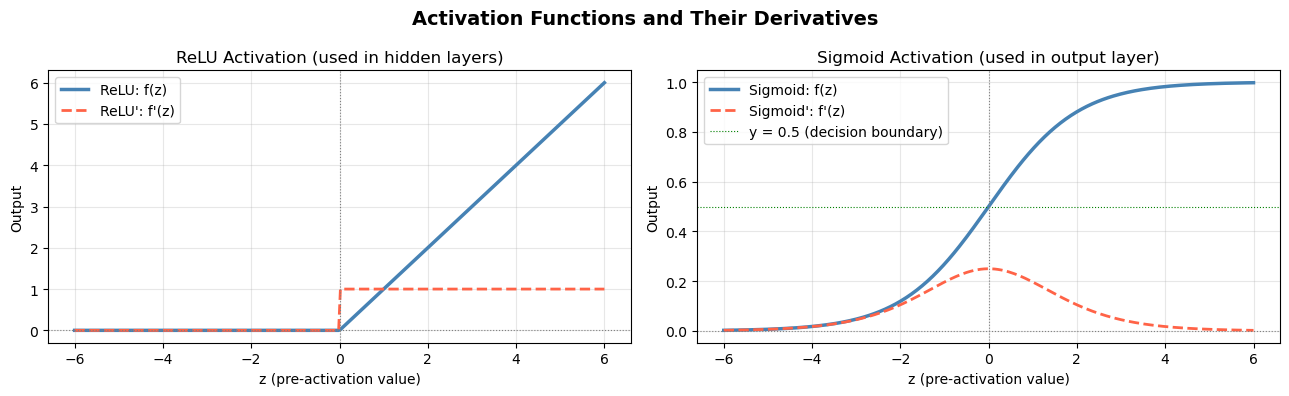

In [4]:
def relu(z):
    """
    ReLU: f(z) = max(0, z)
    Negative inputs are set to 0. Positive inputs pass through unchanged.
    """
    return np.maximum(0, z)   # np.maximum applies element-wise max(0, value)


def relu_derivative(z):
    """
    Derivative of ReLU: f'(z) = 1 where z > 0, else 0.
    
    This is used during backprop to determine how much gradient
    flows through each ReLU neuron. 'Off' neurons (z <= 0) block
    all gradient flow. 'On' neurons (z > 0) pass gradient through unchanged.
    
    IMPORTANT: z here is the PRE-activation value (before relu was applied).
    """
    return np.where(z > 0, 1.0, 0.0)   # 1.0 where z > 0, else 0.0


def sigmoid(z):
    """
    Sigmoid: f(z) = 1 / (1 + e^(-z))
    Squashes any real number into the range (0, 1).
    We clip z to avoid numerical overflow in np.exp().
    """
    z_clipped = np.clip(z, -500, 500)      # Prevent overflow
    return 1.0 / (1.0 + np.exp(-z_clipped))


def sigmoid_derivative(a):
    """
    Derivative of Sigmoid: f'(z) = f(z) * (1 - f(z)) = a * (1 - a)
    
    IMPORTANT: 'a' here is the ALREADY-ACTIVATED output (after sigmoid was applied),
    NOT the pre-activation z. This is what makes sigmoid's derivative so convenient.
    """
    return a * (1.0 - a)


# --- Visualize both activation functions ---
z_values = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ReLU plot
axes[0].plot(z_values, relu(z_values), color='steelblue', linewidth=2.5, label='ReLU: f(z)')
axes[0].plot(z_values, relu_derivative(z_values), color='tomato', linewidth=2, linestyle='--', label="ReLU': f'(z)")
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_title('ReLU Activation (used in hidden layers)', fontsize=12)
axes[0].set_xlabel('z (pre-activation value)')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sigmoid plot
sig_vals = sigmoid(z_values)
axes[1].plot(z_values, sig_vals,                    color='steelblue', linewidth=2.5, label='Sigmoid: f(z)')
axes[1].plot(z_values, sigmoid_derivative(sig_vals), color='tomato',    linewidth=2,   linestyle='--', label="Sigmoid': f'(z)")
axes[1].axhline(0,   color='gray', linewidth=0.8, linestyle=':')
axes[1].axhline(0.5, color='green', linewidth=0.8, linestyle=':', label='y = 0.5 (decision boundary)')
axes[1].axvline(0,   color='gray', linewidth=0.8, linestyle=':')
axes[1].set_title('Sigmoid Activation (used in output layer)', fontsize=12)
axes[1].set_xlabel('z (pre-activation value)')
axes[1].set_ylabel('Output')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Activation Functions and Their Derivatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Loss Function

### Binary Cross-Entropy Loss

This is the standard loss function for binary classification tasks.

```
Loss = -mean( y * log(y_hat) + (1 - y) * log(1 - y_hat) )
```

Where:
- `y` = true label (0 or 1)
- `y_hat` = predicted probability (between 0 and 1)

**Intuition:**

| True Label (y) | Prediction (y_hat) | Loss |
|---|---|---|
| 1 | 0.99 | Very small (correct and confident) |
| 1 | 0.01 | Very large (correct class but wrong prediction) |
| 0 | 0.01 | Very small (correct and confident) |
| 0 | 0.99 | Very large (wrong class, confident) |

The function heavily punishes **confident wrong predictions** and barely penalizes **confident correct predictions**. This shapes the gradient in a way that helps the network improve fast.

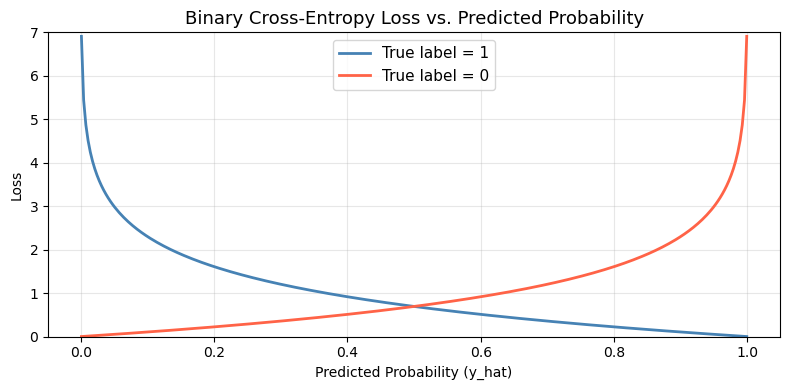

Notice: when the true label is 1 and we predict 0.99, loss is near 0 (good).
But when the true label is 1 and we predict 0.01, loss shoots up (very bad).


In [5]:
def binary_cross_entropy_loss(y_true, y_pred):
    """
    Binary Cross-Entropy Loss.
    
    Formula: Loss = -mean( y * log(y_hat) + (1 - y) * log(1 - y_hat) )
    
    Parameters:
        y_true : true labels,            shape (n_samples,) -- values 0 or 1
        y_pred : predicted probabilities, shape (n_samples,) -- values in (0, 1)
    
    Returns:
        A single scalar float: the average loss across all samples
    """
    # Clip predictions away from 0 and 1 to avoid log(0) = -infinity
    y_pred_clipped = np.clip(y_pred, 1e-12, 1 - 1e-12)
    
    # Compute loss for each sample individually
    loss_per_sample = -(  
        y_true * np.log(y_pred_clipped) +
        (1 - y_true) * np.log(1 - y_pred_clipped)
    )
    
    # Return the average loss (scalar)
    return np.mean(loss_per_sample)


# --- Visualize how the loss changes with prediction quality ---
y_hat_range = np.linspace(0.001, 0.999, 300)

loss_true1 = -np.log(y_hat_range)           # Loss when true label = 1
loss_true0 = -np.log(1 - y_hat_range)       # Loss when true label = 0

plt.figure(figsize=(8, 4))
plt.plot(y_hat_range, loss_true1, color='steelblue', linewidth=2, label='True label = 1')
plt.plot(y_hat_range, loss_true0, color='tomato',    linewidth=2, label='True label = 0')
plt.xlabel('Predicted Probability (y_hat)')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss vs. Predicted Probability', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0, 7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: when the true label is 1 and we predict 0.99, loss is near 0 (good).")
print("But when the true label is 1 and we predict 0.01, loss shoots up (very bad).")

---
## 6. The MLP Class

This is the core of the assignment. The `MLP` class contains:

| Method | What it does |
|---|---|
| `__init__()` | Initializes all weights and biases using He initialization |
| `forward()` | Runs a forward pass: X -> predictions |
| `backward()` | Runs backpropagation: computes gradients for all weights |
| `update_weights()` | Applies gradient descent to update all parameters |
| `train()` | The training loop: forward -> loss -> backward -> update |
| `predict_proba()` | Returns raw probability predictions |
| `predict()` | Returns hard 0/1 class predictions |
| `evaluate()` | Computes accuracy, precision, recall, F1, and confusion matrix |

---

### Weight Initialization (He / Kaiming)

We initialize weights using:
```
W ~ Normal(0, sqrt(2 / n_inputs_to_layer))
```

- **Why not zeros?** All neurons compute the same thing and learn the same thing (symmetry problem). The network never learns anything useful.
- **Why not large random values?** Causes large activations, sigmoid saturates, gradients vanish.
- **He initialization** keeps activations in a healthy range throughout training. It is specifically designed for ReLU networks.

---

### Backpropagation: Step-by-Step

We apply the chain rule layer by layer, going from output back to input:

```
OUTPUT LAYER:
    dz3 = a3 - y                          (BCE + Sigmoid simplifies to this beautifully)
    dW3 = (1/m) * a2.T @ dz3
    db3 = (1/m) * sum(dz3)

HIDDEN LAYER 2:
    da2 = dz3 @ W3.T                      (propagate gradient back through W3)
    dz2 = da2 * relu_derivative(z2)       (propagate back through ReLU)
    dW2 = (1/m) * a1.T @ dz2
    db2 = (1/m) * sum(dz2)

HIDDEN LAYER 1:
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)
    dW1 = (1/m) * X.T @ dz1
    db1 = (1/m) * sum(dz1)
```

The notation `dW1` means "derivative of Loss with respect to W1".

In [6]:
class MLP:
    """
    Multi-Layer Perceptron with architecture:
        Input -> Hidden Layer 1 (ReLU) -> Hidden Layer 2 (ReLU) -> Output (Sigmoid)
    
    We have THREE weight matrices and THREE bias vectors:
        W1, b1 : Input        -> Hidden Layer 1
        W2, b2 : Hidden Layer 1 -> Hidden Layer 2
        W3, b3 : Hidden Layer 2 -> Output
    """

    def __init__(self, n_input, n_hidden1=64, n_hidden2=32, learning_rate=0.01):
        """
        Initialize all weights using He (Kaiming) initialization.
        Biases are initialized to zero.
        
        Parameters:
            n_input       : number of input features (e.g., 20)
            n_hidden1     : neurons in hidden layer 1 (default: 64)
            n_hidden2     : neurons in hidden layer 2 (default: 32)
            learning_rate : gradient descent step size (default: 0.01)
        """
        self.lr = learning_rate   # Store learning rate

        # ---- Layer 1: Input -> Hidden Layer 1 ----
        # Shape (n_input, n_hidden1): one weight per (input feature, hidden1 neuron) pair
        self.W1 = np.random.randn(n_input,   n_hidden1) * np.sqrt(2.0 / n_input)
        self.b1 = np.zeros((1, n_hidden1))   # Bias shape: (1, n_hidden1), broadcast across samples

        # ---- Layer 2: Hidden Layer 1 -> Hidden Layer 2 ----
        self.W2 = np.random.randn(n_hidden1, n_hidden2) * np.sqrt(2.0 / n_hidden1)
        self.b2 = np.zeros((1, n_hidden2))

        # ---- Output Layer: Hidden Layer 2 -> Output ----
        # Only 1 output neuron for binary classification
        self.W3 = np.random.randn(n_hidden2, 1)         * np.sqrt(2.0 / n_hidden2)
        self.b3 = np.zeros((1, 1))

        # Cache stores intermediate values from the forward pass.
        # Backprop needs these values to compute gradients.
        self.cache = {}

    # ------------------------------------------------------------------
    # FORWARD PASS
    # ------------------------------------------------------------------

    def forward(self, X):
        """
        Forward pass: compute predictions from input X.
        Data flows: X -> Layer 1 -> Layer 2 -> Output Layer -> y_hat
        
        At each layer:
            z = X @ W + b     (linear transformation)
            a = activation(z) (non-linear activation)
        
        All intermediate values (z1, a1, z2, a2, z3, a3) are cached
        so that backpropagation can use them later.
        
        Parameters:
            X : input data, shape (n_samples, n_features)
        
        Returns:
            a3 : predicted probabilities, shape (n_samples, 1)
        """
        # ---- Hidden Layer 1 ----
        # z1 shape: (n_samples, n_hidden1) = (n_samples, n_input) @ (n_input, n_hidden1)
        z1 = X @ self.W1 + self.b1
        a1 = relu(z1)            # Apply ReLU: negative values become 0

        # ---- Hidden Layer 2 ----
        # z2 shape: (n_samples, n_hidden2) = (n_samples, n_hidden1) @ (n_hidden1, n_hidden2)
        z2 = a1 @ self.W2 + self.b2
        a2 = relu(z2)

        # ---- Output Layer ----
        # z3 shape: (n_samples, 1) = (n_samples, n_hidden2) @ (n_hidden2, 1)
        z3 = a2 @ self.W3 + self.b3
        a3 = sigmoid(z3)         # Sigmoid outputs a probability between 0 and 1

        # Cache all values -- backprop will walk this path in reverse
        self.cache = {
            'X':  X,
            'z1': z1, 'a1': a1,
            'z2': z2, 'a2': a2,
            'z3': z3, 'a3': a3
        }

        return a3

    # ------------------------------------------------------------------
    # BACKWARD PASS (BACKPROPAGATION)
    # ------------------------------------------------------------------

    def backward(self, y_true):
        """
        Backpropagation: compute gradients of the loss w.r.t. all weights.
        
        We apply the chain rule from output layer back to input layer.
        Each gradient tells us: "if I increase this weight slightly,
        does the loss go up or down, and by how much?"
        
        Parameters:
            y_true : true labels, shape (n_samples,)
        
        Returns:
            Dictionary of gradients: dW1, db1, dW2, db2, dW3, db3
        """
        m = y_true.shape[0]     # Number of samples (for averaging gradients)

        # Retrieve cached values from the forward pass
        X  = self.cache['X']
        z1 = self.cache['z1'];  a1 = self.cache['a1']
        z2 = self.cache['z2'];  a2 = self.cache['a2']
        a3 = self.cache['a3']

        # Reshape y_true from (m,) to (m, 1) for consistent matrix shapes
        y = y_true.reshape(-1, 1)

        # ==============================================================
        # OUTPUT LAYER GRADIENT
        # ==============================================================
        # When BCE Loss is combined with Sigmoid, the gradient of the
        # loss w.r.t. z3 simplifies beautifully to: (a3 - y).
        # This is why BCE + Sigmoid are always used together.
        dz3 = a3 - y                                         # shape: (m, 1)

        # Gradient w.r.t. W3: dL/dW3 = (1/m) * a2.T @ dz3
        dW3 = (1 / m) * a2.T @ dz3                          # shape: (n_hidden2, 1)

        # Gradient w.r.t. b3: sum over samples (axis=0), keep as (1, 1)
        db3 = (1 / m) * np.sum(dz3, axis=0, keepdims=True)  # shape: (1, 1)

        # ==============================================================
        # HIDDEN LAYER 2 GRADIENT
        # ==============================================================
        # Step 1: propagate gradient back through W3
        da2 = dz3 @ self.W3.T                               # shape: (m, n_hidden2)

        # Step 2: propagate back through ReLU of layer 2
        # Element-wise multiply (*) with the ReLU derivative (0 or 1 mask)
        dz2 = da2 * relu_derivative(z2)                     # shape: (m, n_hidden2)

        dW2 = (1 / m) * a1.T @ dz2                          # shape: (n_hidden1, n_hidden2)
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)  # shape: (1, n_hidden2)

        # ==============================================================
        # HIDDEN LAYER 1 GRADIENT
        # ==============================================================
        da1 = dz2 @ self.W2.T                               # shape: (m, n_hidden1)
        dz1 = da1 * relu_derivative(z1)                     # shape: (m, n_hidden1)

        # Layer 1 connects directly to input X, so we use X here
        dW1 = (1 / m) * X.T @ dz1                           # shape: (n_input, n_hidden1)
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)  # shape: (1, n_hidden1)

        return {
            'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2,
            'dW3': dW3, 'db3': db3
        }

    # ------------------------------------------------------------------
    # WEIGHT UPDATE
    # ------------------------------------------------------------------

    def update_weights(self, gradients):
        """
        Gradient Descent: update all weights by stepping in the downhill direction.
        
        Rule: W = W - learning_rate * gradient
        
        We SUBTRACT the gradient because the gradient points uphill
        (direction of steepest increase), and we want to DECREASE the loss.
        
        Parameters:
            gradients : dictionary returned by backward()
        """
        self.W1 -= self.lr * gradients['dW1']
        self.b1 -= self.lr * gradients['db1']
        self.W2 -= self.lr * gradients['dW2']
        self.b2 -= self.lr * gradients['db2']
        self.W3 -= self.lr * gradients['dW3']
        self.b3 -= self.lr * gradients['db3']

    # ------------------------------------------------------------------
    # TRAINING LOOP
    # ------------------------------------------------------------------

    def train(self, X_train, y_train, X_val, y_val, epochs=200, print_every=20):
        """
        Train the MLP for a fixed number of epochs.
        
        One epoch = one complete pass through all training data.
        Per epoch, we do:
            1. Forward pass       -> compute predictions
            2. Compute loss       -> measure how wrong we are
            3. Backward pass      -> compute gradients
            4. Update weights     -> take one gradient descent step
        
        We also compute validation loss each epoch (without updating weights)
        to monitor for overfitting.
        
        Parameters:
            X_train     : training features,   shape (n_train, n_features)
            y_train     : training labels,     shape (n_train,)
            X_val       : validation features, shape (n_val, n_features)
            y_val       : validation labels,   shape (n_val,)
            epochs      : number of full passes through training data
            print_every : print progress every N epochs
        
        Returns:
            history : dict with lists of train_loss and val_loss per epoch
        """
        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(1, epochs + 1):

            # Step 1: Forward pass on training data
            y_pred_train = self.forward(X_train)       # shape: (n_train, 1)

            # Step 2: Compute training loss
            train_loss = binary_cross_entropy_loss(y_train, y_pred_train.ravel())

            # Step 3: Backward pass
            gradients = self.backward(y_train)

            # Step 4: Update weights
            self.update_weights(gradients)

            # Validation loss (forward pass only -- NO weight updates!)
            y_pred_val = self.forward(X_val)
            val_loss   = binary_cross_entropy_loss(y_val, y_pred_val.ravel())

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)

            if epoch % print_every == 0 or epoch == 1:
                print(f"Epoch {epoch:4d}/{epochs} | "
                      f"Train Loss: {train_loss:.4f} | "
                      f"Val Loss: {val_loss:.4f}")

        return history

    # ------------------------------------------------------------------
    # PREDICTION AND EVALUATION
    # ------------------------------------------------------------------

    def predict_proba(self, X):
        """Return raw sigmoid probabilities for class 1, shape (n_samples,)."""
        return self.forward(X).ravel()    # ravel() flattens (n,1) to (n,)

    def predict(self, X, threshold=0.5):
        """
        Return hard 0/1 class labels.
        If predicted probability >= threshold, predict class 1. Else class 0.
        """
        return (self.predict_proba(X) >= threshold).astype(int)

    def evaluate(self, X, y_true):
        """
        Compute evaluation metrics:
        
            Accuracy  = (TP + TN) / total
            Precision = TP / (TP + FP)   -- of all predicted positives, how many are real?
            Recall    = TP / (TP + FN)   -- of all actual positives, how many did we catch?
            F1-Score  = 2 * P * R / (P + R)  -- harmonic mean of precision and recall
        
        Confusion Matrix:
            TP = True Positive  (predicted 1, actually 1)
            TN = True Negative  (predicted 0, actually 0)
            FP = False Positive (predicted 1, actually 0) -- false alarm
            FN = False Negative (predicted 0, actually 1) -- missed detection
        """
        y_pred = self.predict(X)

        TP = int(np.sum((y_pred == 1) & (y_true == 1)))
        TN = int(np.sum((y_pred == 0) & (y_true == 0)))
        FP = int(np.sum((y_pred == 1) & (y_true == 0)))
        FN = int(np.sum((y_pred == 0) & (y_true == 1)))

        accuracy  = (TP + TN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)

        return {
            'accuracy':  accuracy,
            'precision': precision,
            'recall':    recall,
            'f1_score':  f1,
            'confusion_matrix': {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}
        }


print("MLP class defined successfully.")

MLP class defined successfully.


---
## 7. Initialize and Inspect the Model

Before training, let's create the model and inspect its weight shapes and parameter count.

In [7]:
# Create the model
model = MLP(
    n_input=X_train.shape[1],   # 20 input features
    n_hidden1=64,               # 64 neurons in hidden layer 1
    n_hidden2=32,               # 32 neurons in hidden layer 2
    learning_rate=0.05          # Learning rate (step size for gradient descent)
)

# Count total trainable parameters
total_params = (
    model.W1.size + model.b1.size +
    model.W2.size + model.b2.size +
    model.W3.size + model.b3.size
)

print("Model Architecture Summary")
print("-" * 50)
print(f"{'Layer':<20} {'Weight Shape':<18} {'Bias Shape':<15} {'Params'}")
print("-" * 50)
print(f"{'Input -> Hidden 1':<20} {str(model.W1.shape):<18} {str(model.b1.shape):<15} {model.W1.size + model.b1.size}")
print(f"{'Hidden 1 -> Hidden 2':<20} {str(model.W2.shape):<18} {str(model.b2.shape):<15} {model.W2.size + model.b2.size}")
print(f"{'Hidden 2 -> Output':<20} {str(model.W3.shape):<18} {str(model.b3.shape):<15} {model.W3.size + model.b3.size}")
print("-" * 50)
print(f"{'Total':<20} {'':18} {'':15} {total_params}")

Model Architecture Summary
--------------------------------------------------
Layer                Weight Shape       Bias Shape      Params
--------------------------------------------------
Input -> Hidden 1    (20, 64)           (1, 64)         1344
Hidden 1 -> Hidden 2 (64, 32)           (1, 32)         2080
Hidden 2 -> Output   (32, 1)            (1, 1)          33
--------------------------------------------------
Total                                                   3457


---
## 8. Train the Model

We run 200 epochs of gradient descent. Watch the loss decrease with each epoch — this is the network learning.

Both **training loss** and **validation loss** are tracked:
- If both decrease together: the model is learning well.
- If training loss keeps dropping but validation loss rises: the model is **overfitting** (memorizing training data instead of generalizing).

In [8]:
print("Starting training...")
print("-" * 55)

history = model.train(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val_norm,
    y_val=y_val,
    epochs=200,
    print_every=20
)

print("-" * 55)
print("Training complete.")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss:   {history['val_loss'][-1]:.4f}")

Starting training...
-------------------------------------------------------
Epoch    1/200 | Train Loss: 0.8320 | Val Loss: 0.7545
Epoch   20/200 | Train Loss: 0.5155 | Val Loss: 0.5311
Epoch   40/200 | Train Loss: 0.4227 | Val Loss: 0.4510
Epoch   60/200 | Train Loss: 0.3641 | Val Loss: 0.3978
Epoch   80/200 | Train Loss: 0.3222 | Val Loss: 0.3602
Epoch  100/200 | Train Loss: 0.2893 | Val Loss: 0.3314
Epoch  120/200 | Train Loss: 0.2621 | Val Loss: 0.3096
Epoch  140/200 | Train Loss: 0.2395 | Val Loss: 0.2924
Epoch  160/200 | Train Loss: 0.2205 | Val Loss: 0.2784
Epoch  180/200 | Train Loss: 0.2040 | Val Loss: 0.2669
Epoch  200/200 | Train Loss: 0.1899 | Val Loss: 0.2572
-------------------------------------------------------
Training complete.
  Final Train Loss: 0.1899
  Final Val Loss:   0.2572


---
## 9. Plot Training History

Visualizing the loss curves is a standard and essential step in diagnosing training:

- Both curves going **down and staying close** = healthy training
- **Val loss >> Train loss** = overfitting
- Curves that **don't decrease much** = learning rate too small, or the model is too shallow

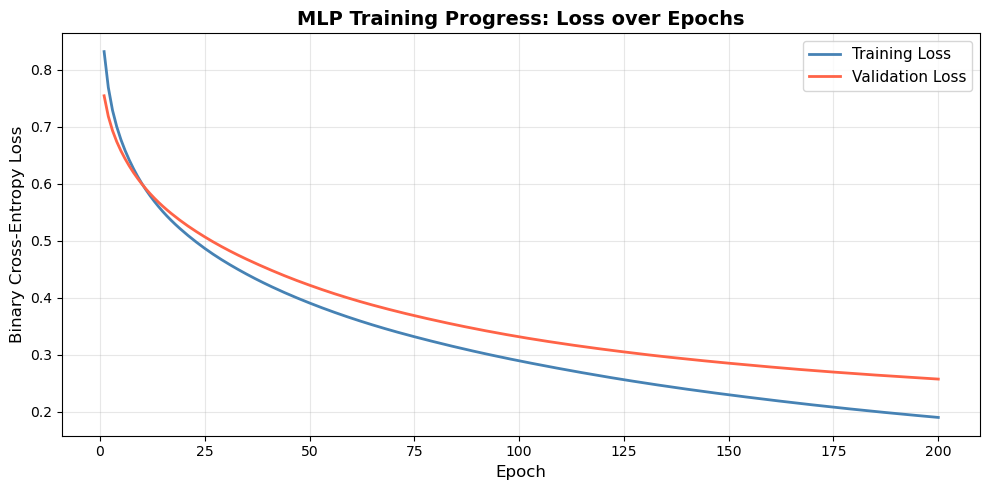

Training loss reduced by 77.2% over 200 epochs.
  Epoch 1:   0.8320
  Epoch 200: 0.1899


In [9]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history['train_loss'], label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(epochs_range, history['val_loss'],   label='Validation Loss', color='tomato',    linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.title('MLP Training Progress: Loss over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Improvement summary
initial_train_loss = history['train_loss'][0]
final_train_loss   = history['train_loss'][-1]
reduction_pct      = (1 - final_train_loss / initial_train_loss) * 100

print(f"Training loss reduced by {reduction_pct:.1f}% over 200 epochs.")
print(f"  Epoch 1:   {initial_train_loss:.4f}")
print(f"  Epoch 200: {final_train_loss:.4f}")

---
## 10. Evaluation

We evaluate the model on both the **training set** and the **test set**.

### Metrics Explained

| Metric | Formula | What it means |
|---|---|---|
| **Accuracy** | (TP + TN) / total | Overall fraction of correct predictions |
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many are truly positive? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did we correctly identify? |
| **F1-Score** | 2*P*R / (P+R) | Harmonic mean of Precision and Recall |

### The Confusion Matrix

```
                 Predicted: 0    Predicted: 1
Actual: 0    [  TN (correct)  |  FP (false alarm)  ]
Actual: 1    [  FN (missed)   |  TP (correct)      ]
```

In [10]:
def print_report(metrics, dataset_name):
    """Pretty-print the evaluation metrics."""
    cm = metrics['confusion_matrix']
    print(f"\n{'='*52}")
    print(f"  EVALUATION REPORT -- {dataset_name} Set")
    print(f"{'='*52}")
    print(f"  Accuracy  : {metrics['accuracy']:.4f}   ({metrics['accuracy']*100:.2f}%)")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1_score']:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    True Positives  (TP) = {cm['TP']:4d}   predicted 1, actually 1")
    print(f"    True Negatives  (TN) = {cm['TN']:4d}   predicted 0, actually 0")
    print(f"    False Positives (FP) = {cm['FP']:4d}   predicted 1, actually 0  (false alarm)")
    print(f"    False Negatives (FN) = {cm['FN']:4d}   predicted 0, actually 1  (missed)")
    print(f"{'='*52}")


# Evaluate on training set
train_metrics = model.evaluate(X_train, y_train)
print_report(train_metrics, "Training")

# Evaluate on test set (the honest, final evaluation)
test_metrics = model.evaluate(X_test_norm, y_test)
print_report(test_metrics, "Test")


  EVALUATION REPORT -- Training Set
  Accuracy  : 0.9386   (93.86%)
  Precision : 0.9397
  Recall    : 0.9370
  F1-Score  : 0.9383
  Confusion Matrix:
    True Positives  (TP) =  327   predicted 1, actually 1
    True Negatives  (TN) =  330   predicted 0, actually 0
    False Positives (FP) =   21   predicted 1, actually 0  (false alarm)
    False Negatives (FN) =   22   predicted 0, actually 1  (missed)

  EVALUATION REPORT -- Test Set
  Accuracy  : 0.8933   (89.33%)
  Precision : 0.8537
  Recall    : 0.9459
  F1-Score  : 0.8974
  Confusion Matrix:
    True Positives  (TP) =   70   predicted 1, actually 1
    True Negatives  (TN) =   64   predicted 0, actually 0
    False Positives (FP) =   12   predicted 1, actually 0  (false alarm)
    False Negatives (FN) =    4   predicted 0, actually 1  (missed)


---
## 11. Visualize the Confusion Matrix

A visual confusion matrix makes it easy to see where the model is making mistakes.

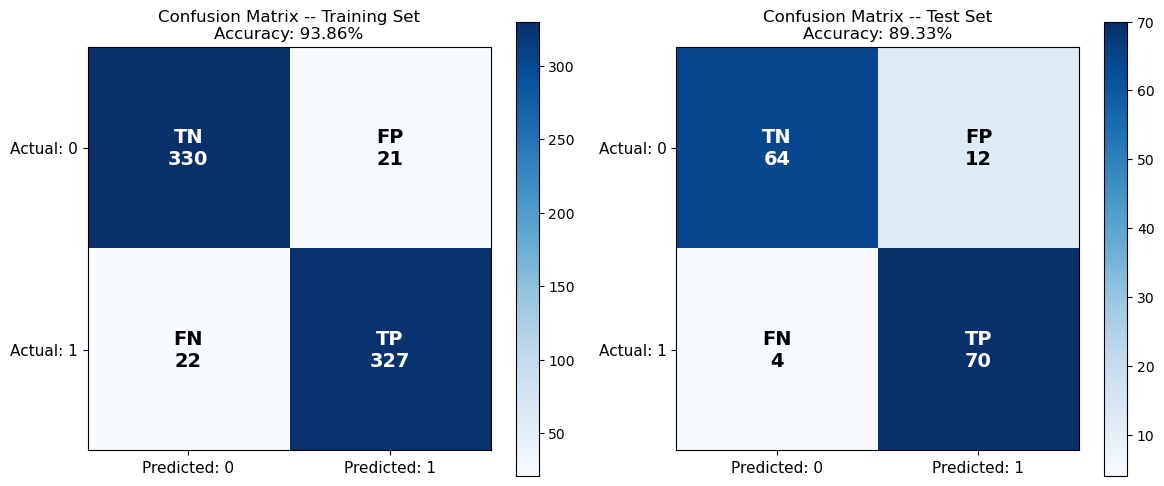

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metrics, title in zip(
    axes,
    [train_metrics, test_metrics],
    ['Training Set', 'Test Set']
):
    cm = metrics['confusion_matrix']

    # Arrange as 2x2 matrix: [[TN, FP], [FN, TP]]
    matrix = np.array([[cm['TN'], cm['FP']],
                        [cm['FN'], cm['TP']]])

    im = ax.imshow(matrix, cmap='Blues')

    # Annotate each cell
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{labels[i][j]}\n{matrix[i, j]}",
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if matrix[i, j] > matrix.max() / 2 else 'black')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted: 0', 'Predicted: 1'], fontsize=11)
    ax.set_yticklabels(['Actual: 0', 'Actual: 1'], fontsize=11)
    ax.set_title(f'Confusion Matrix -- {title}\nAccuracy: {metrics["accuracy"]*100:.2f}%', fontsize=12)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

---
## 12. Summary

Here is everything we built, at a glance:

### System Design

```
INPUT (20 features)
    |
    | W1 (20x64) + b1
    v
HIDDEN LAYER 1 (64 neurons, ReLU)
    |
    | W2 (64x32) + b2
    v
HIDDEN LAYER 2 (32 neurons, ReLU)
    |
    | W3 (32x1) + b3
    v
OUTPUT (1 neuron, Sigmoid -> probability)
```

### Implementation Checklist

| Component | Status |
|---|---|
| Data pre-processing (normalization, splitting) | Done |
| Activation functions (ReLU, Sigmoid + derivatives) | Done |
| Loss function (Binary Cross-Entropy) | Done |
| Forward Pass | Done |
| Backpropagation (chain rule, all layers) | Done |
| Gradient Descent weight updates | Done |
| Training loop with validation monitoring | Done |
| Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix) | Done |
| Plots (loss curves, confusion matrix) | Done |
| Zero use of TensorFlow / PyTorch / Keras | Confirmed |

### Key Takeaways

1. **A neural network is just a chain of linear transformations + non-linearities.** ReLU is what gives the network its power to approximate any function.

2. **Backpropagation is the chain rule applied to every layer.** It efficiently computes how much each weight contributed to the error.

3. **Gradient descent is the learning mechanism.** It nudges every weight slightly in the direction that reduces the loss.

4. **The test set is sacred.** It should never influence training -not even for computing normalization statistics.